### Content: data cleaning
- remove wrong coordinates (latitude or longitude less than zero).
- fix point_trip_id: some ID repeat themselves after some time: must modify them so that each ID is unique for each trip.
- filter out data outiside the area of interest (where scooters are allowed) using alphashape.
- remove anomalous trips (e.g., few trips last hours, which is very likely a mistake).

Produce *tripsv3_cleaned.parquet*.

### Issue 1: filter out wrong coordinates

In [2]:
import pandas as pd
import geopandas as gpd
import numpy as np
import alphashape
from shapely.geometry import Point, Polygon

In [4]:
data = pd.read_parquet('data/tripsv3.parquet')
data.head(2)

,operator,trip_operator_id,trip_vehicle_id,trip_id,trip_start_epoch,trip_end_epoch,trip_start,trip_end,trip_duration_break_excluded,trip_origin_time,...,trip_destination_time,trip_destination_latitude,trip_destination_longitude,trip_points_num,trip_points_numall,trip_length,trip_user_id,trip_mode,trip_accuracy,trip_properties
0,BIT,Bit Mobility,3s1958,00000f26-0000-1000-85d6-5b7d6a617b60,1640991067603.000000,1640991916760.000000,2021-12-31 22:51:07+00:00,2021-12-31 23:05:16+00:00,14.150000,2021-12-31 22:51:07+00:00,...,2021-12-31 23:05:16+00:00,46.069185,11.125873,2.000000,2.000000,2420.000000,None,scooter,15.0,None
1,BIT,Bit Mobility,3s2628,00000f55-0000-1000-85f5-5b7d6a617b60,1640991152874.000000,1640991922241.000000,2021-12-31 22:52:32+00:00,2021-12-31 23:05:22+00:00,12.816667,2021-12-31 22:52:32+00:00,...,2021-12-31 23:05:22+00:00,46.069166,11.125992,2.000000,2.000000,2290.000000,None,scooter,15.0,None


In [11]:
len(data.trip_vehicle_id.unique()) # numero di e-scooter presenti

645

In [35]:
# drop columns filled with None and redundant information
data = data.drop(['trip_properties', 'trip_user_id', 'trip_operator_id', 'trip_start_epoch', 'trip_end_epoch', 'trip_origin_time', 'trip_destination_time', 'trip_points_num', 'trip_points_numall', 'trip_mode'], axis=1) 

In [37]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110299 entries, 0 to 110298
Data columns (total 13 columns):
 #   Column                        Non-Null Count   Dtype              
---  ------                        --------------   -----              
 0   operator                      110299 non-null  object             
 1   trip_operator_id              110299 non-null  object             
 2   trip_vehicle_id               110299 non-null  object             
 3   trip_id                       110299 non-null  object             
 4   trip_start                    110299 non-null  datetime64[ns, UTC]
 5   trip_end                      110299 non-null  datetime64[ns, UTC]
 6   trip_duration_break_excluded  110299 non-null  object             
 7   trip_origin_latitude          110299 non-null  object             
 8   trip_origin_longitude         110299 non-null  object             
 9   trip_destination_latitude     110299 non-null  object             
 10  trip_destination_lon

In [38]:
data[data.trip_origin_latitude <= 0]

,operator,trip_operator_id,trip_vehicle_id,trip_id,trip_start,trip_end,trip_duration_break_excluded,trip_origin_latitude,trip_origin_longitude,trip_destination_latitude,trip_destination_longitude,trip_length,trip_accuracy
203,VENTO,WIND,S0037293,b3d0b458b5fb,2021-08-20 07:26:55+00:00,2021-08-20 07:36:17+00:00,9.366667,0.000000,0.000000,0.000000,0.000000,1544.000000,NaN
841,VENTO,WIND,S0026877,a47842fe8b08,2021-10-09 09:16:39+00:00,2021-10-09 09:19:03+00:00,2.400000,0.000000,0.000000,0.000000,0.000000,303.000000,NaN
876,VENTO,WIND,S0026877,f29b67080ff2,2021-08-30 17:29:22+00:00,2021-08-30 17:32:41+00:00,3.316667,0.000000,0.000000,0.000000,0.000000,11.000000,NaN
1047,VENTO,WIND,S0042528,b29d4f6df8bd,2021-09-02 05:26:19+00:00,2021-09-02 05:30:04+00:00,3.750000,0.000000,0.000000,0.000000,0.000000,35.000000,NaN
1522,VENTO,WIND,S0030509,3d581f17fa2d,2021-09-06 10:19:10+00:00,2021-09-06 10:20:50+00:00,1.666667,0.000000,0.000000,0.000000,0.000000,212.000000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
28897,VENTO,WIND,S0034614,ad45d3f6363d,2021-11-30 11:09:58+00:00,2021-11-30 11:16:55+00:00,6.950000,0.000000,0.000000,0.000000,0.000000,1402.000000,NaN
28898,VENTO,WIND,S0034614,94cd1b9cf8f3,2021-11-30 11:21:34+00:00,2021-11-30 11:26:24+00:00,4.833333,0.000000,0.000000,0.000000,0.000000,674.000000,NaN
28902,VENTO,WIND,S0034369,89ada6f07274,2021-11-30 16:48:55+00:00,2021-11-30 16:57:17+00:00,8.366667,0.000000,0.000000,0.000000,0.000000,1445.000000,NaN
28918,VENTO,WIND,S0034369,3f34cb54849b,2021-12-06 18:36:44+00:00,2021-12-06 18:41:47+00:00,5.050000,0.000000,0.000000,0.000000,0.000000,62.000000,NaN


In [39]:
data = data[data.trip_origin_latitude >= 0]
data = data[data.trip_origin_longitude >= 0]
data = data[data.trip_destination_latitude >= 0]
data = data[data.trip_destination_longitude >= 0]
data

,operator,trip_operator_id,trip_vehicle_id,trip_id,trip_start,trip_end,trip_duration_break_excluded,trip_origin_latitude,trip_origin_longitude,trip_destination_latitude,trip_destination_longitude,trip_length,trip_accuracy
0,BIT,Bit Mobility,3s1958,00000f26-0000-1000-85d6-5b7d6a617b60,2021-12-31 22:51:07+00:00,2021-12-31 23:05:16+00:00,14.150000,46.069058,11.125847,46.069185,11.125873,2420.000000,15.0
1,BIT,Bit Mobility,3s2628,00000f55-0000-1000-85f5-5b7d6a617b60,2021-12-31 22:52:32+00:00,2021-12-31 23:05:22+00:00,12.816667,46.069980,11.123846,46.069166,11.125992,2290.000000,15.0
2,BIT,Bit Mobility,3S4007,00002677-0000-1000-9537-5b7d6a617b60,2021-12-31 23:32:46+00:00,2021-12-31 23:34:37+00:00,1.850000,46.064904,11.123108,46.064540,11.120380,210.000000,15.0
3,BIT,Bit Mobility,3s2628,000002e4-0000-1000-9784-5b7d6a617b60,2021-12-31 23:26:03+00:00,2021-12-31 23:37:03+00:00,11.000000,46.069138,11.125999,46.067448,11.124116,950.000000,15.0
4,BIT,Bit Mobility,3s1958,0000101c-0000-1000-a03c-5b7d6a617b60,2021-12-31 23:26:22+00:00,2021-12-31 23:45:04+00:00,18.700000,46.069156,11.125829,46.069609,11.125088,1900.000000,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
110294,BIT,Bit Mobility,3s2603,0000231d-0000-1000-818d-5b7d6a617b60,2022-05-04 22:18:13+00:00,2022-05-04 22:22:55+00:00,4.683333,46.066114,11.131366,46.069898,11.119706,1240.000000,15.0
110295,BIT,Bit Mobility,3s170,00000bd7-0000-1000-8bf7-5b7d6a617b60,2022-05-04 22:10:13+00:00,2022-05-04 22:31:08+00:00,20.916667,46.068879,11.125948,46.057510,11.125230,3350.000000,15.0
110296,BIT,Bit Mobility,3s2644,00000ce6-0000-1000-99f6-5b7d6a617b60,2022-05-04 22:05:28+00:00,2022-05-04 22:12:03+00:00,6.566667,46.069549,11.119470,46.061051,11.124934,1150.000000,15.0
110297,BIT,Bit Mobility,3s3025,00000341-0000-1000-a011-5b7d6a617b60,2022-05-04 22:51:02+00:00,2022-05-04 22:53:26+00:00,2.383333,46.066806,11.120345,46.061369,11.118962,670.000000,15.0


In [40]:
data = data.reset_index()

### Issue 2: ID repeat themselves after some time

In [42]:
data[data.trip_id =='00000001-0000-1000-9ec1-5b7d6a617b60'] ## same ID appears in different days

,index,operator,trip_operator_id,trip_vehicle_id,trip_id,trip_start,trip_end,trip_duration_break_excluded,trip_origin_latitude,trip_origin_longitude,trip_destination_latitude,trip_destination_longitude,trip_length,trip_accuracy
930,930,BIT,Bit Mobility,3s2967,00000001-0000-1000-9ec1-5b7d6a617b60,2022-01-08 13:44:10+00:00,2022-01-08 13:52:01+00:00,7.833333,46.097525,11.102425,46.079888,11.117030,2240.000000,15.0
2327,2327,BIT,Bit Mobility,3s1261,00000001-0000-1000-9ec1-5b7d6a617b60,2022-01-12 15:44:15+00:00,2022-01-12 15:55:02+00:00,10.766667,46.073578,11.120929,46.094501,11.119510,2940.000000,15.0
29874,29875,BIT,Bit Mobility,3S4280,00000001-0000-1000-9ec1-5b7d6a617b60,2020-12-03 14:14:57+00:00,2020-12-03 14:44:40+00:00,29.700000,46.060532,11.115307,46.060551,11.115251,4160.000000,NaN
34184,34185,BIT,Bit Mobility,3s3510,00000001-0000-1000-9ec1-5b7d6a617b60,2021-02-16 15:05:28+00:00,2021-02-16 15:15:17+00:00,9.816667,46.071957,11.120046,46.060024,11.133364,2299.000000,NaN
39474,39475,BIT,Bit Mobility,3S4657,00000001-0000-1000-9ec1-5b7d6a617b60,2021-03-20 20:14:08+00:00,2021-03-20 20:52:02+00:00,37.900000,46.061020,11.124775,46.061253,11.126844,6320.000000,NaN
42662,42663,BIT,Bit Mobility,3S4675,00000001-0000-1000-9ec1-5b7d6a617b60,2021-05-04 14:19:43+00:00,2021-05-04 14:24:13+00:00,4.483333,46.073273,11.126663,46.082153,11.122440,1230.000000,NaN
47079,47080,BIT,Bit Mobility,3S4786,00000001-0000-1000-9ec1-5b7d6a617b60,2021-05-19 17:48:56+00:00,2021-05-19 17:55:59+00:00,7.033333,46.083977,11.119506,46.069721,11.121650,1830.000000,NaN
51655,51656,BIT,Bit Mobility,3s2900,00000001-0000-1000-9ec1-5b7d6a617b60,2021-06-02 15:27:28+00:00,2021-06-02 15:30:45+00:00,3.283333,46.059067,11.127118,46.053356,11.132645,889.000000,NaN
60808,60809,BIT,Bit Mobility,3S3865,00000001-0000-1000-9ec1-5b7d6a617b60,2021-07-20 15:48:54+00:00,2021-07-20 16:02:18+00:00,13.400000,46.073626,11.120928,46.048140,11.128789,3610.000000,NaN
63008,63009,BIT,Bit Mobility,3S4654,00000001-0000-1000-9ec1-5b7d6a617b60,2021-07-29 16:46:27+00:00,2021-07-29 16:54:55+00:00,8.450000,46.060976,11.124786,46.066058,11.114498,1880.000000,NaN


In [43]:
# add date column
lst_gg = []
for gg in range(len(data.trip_start)):
  lst_gg.append(data.trip_start[gg].date())
data['date'] = lst_gg

In [44]:
# create a unique id as concatenation of point_trip_id and date
id=[]
for r in range(len(data)):
  id.append(str(data.trip_id[r])+'_'+str(data.date[r]))
data['unique_id'] = id

In [45]:
data.head()

,index,operator,trip_operator_id,trip_vehicle_id,trip_id,trip_start,trip_end,trip_duration_break_excluded,trip_origin_latitude,trip_origin_longitude,trip_destination_latitude,trip_destination_longitude,trip_length,trip_accuracy,date,unique_id
0,0,BIT,Bit Mobility,3s1958,00000f26-0000-1000-85d6-5b7d6a617b60,2021-12-31 22:51:07+00:00,2021-12-31 23:05:16+00:00,14.150000,46.069058,11.125847,46.069185,11.125873,2420.000000,15.0,2021-12-31,00000f26-0000-1000-85d6-5b7d6a617b60_2021-12-31
1,1,BIT,Bit Mobility,3s2628,00000f55-0000-1000-85f5-5b7d6a617b60,2021-12-31 22:52:32+00:00,2021-12-31 23:05:22+00:00,12.816667,46.069980,11.123846,46.069166,11.125992,2290.000000,15.0,2021-12-31,00000f55-0000-1000-85f5-5b7d6a617b60_2021-12-31
2,2,BIT,Bit Mobility,3S4007,00002677-0000-1000-9537-5b7d6a617b60,2021-12-31 23:32:46+00:00,2021-12-31 23:34:37+00:00,1.850000,46.064904,11.123108,46.064540,11.120380,210.000000,15.0,2021-12-31,00002677-0000-1000-9537-5b7d6a617b60_2021-12-31
3,3,BIT,Bit Mobility,3s2628,000002e4-0000-1000-9784-5b7d6a617b60,2021-12-31 23:26:03+00:00,2021-12-31 23:37:03+00:00,11.000000,46.069138,11.125999,46.067448,11.124116,950.000000,15.0,2021-12-31,000002e4-0000-1000-9784-5b7d6a617b60_2021-12-31
4,4,BIT,Bit Mobility,3s1958,0000101c-0000-1000-a03c-5b7d6a617b60,2021-12-31 23:26:22+00:00,2021-12-31 23:45:04+00:00,18.700000,46.069156,11.125829,46.069609,11.125088,1900.000000,15.0,2021-12-31,0000101c-0000-1000-a03c-5b7d6a617b60_2021-12-31


In [47]:
data = data.drop(['index', 'trip_id', 'date'], axis=1) 

In [48]:
data.head(2)

,operator,trip_vehicle_id,trip_start,trip_end,trip_duration_break_excluded,trip_origin_latitude,trip_origin_longitude,trip_destination_latitude,trip_destination_longitude,trip_length,trip_accuracy,unique_id
0,BIT,3s1958,2021-12-31 22:51:07+00:00,2021-12-31 23:05:16+00:00,14.150000,46.069058,11.125847,46.069185,11.125873,2420.000000,15.0,00000f26-0000-1000-85d6-5b7d6a617b60_2021-12-31
1,BIT,3s2628,2021-12-31 22:52:32+00:00,2021-12-31 23:05:22+00:00,12.816667,46.069980,11.123846,46.069166,11.125992,2290.000000,15.0,00000f55-0000-1000-85f5-5b7d6a617b60_2021-12-31


### Issue 3: filter out trips that start outside the area where e-scooters are allowed

In [51]:
data = gpd.GeoDataFrame(data, crs='EPSG:4326', geometry=gpd.points_from_xy(data.trip_origin_longitude, data.trip_origin_latitude))

In [53]:
# caricamento aree dove sono concessi gli spostamenti
area = gpd.read_file("data/static/ambito_esercizio_monopattini.shp") 

In [54]:
area

,ogc_fid,area,perimetro,fumetto,descrizion,geometry
0,69,382183.0,6483.0,Piedicastello,Piedicastello,"POLYGON ((663578.614 5104176.203, 663552.243 5..."
1,76,397561.0,5947.0,San Lazzaro - Lamar,San Lazzaro - Lamar,"POLYGON ((663046.736 5111202.450, 663140.429 5..."
2,90,10687849.0,29010.0,Trento,Trento,"POLYGON ((664269.286 5105158.048, 664272.050 5..."
3,84,941531.0,5720.0,Gardolo,Gardolo,"POLYGON ((662829.584 5108862.129, 662833.817 5..."
4,82,161847.0,3360.0,Vela,Vela,"POLYGON ((662639.688 5104893.315, 662634.213 5..."
5,83,824374.0,5758.0,Gardolo,Gardolo,"POLYGON ((662154.871 5108224.534, 662188.913 5..."
6,86,364694.0,3610.0,Roncafort,Roncafort,"POLYGON ((662740.584 5106685.497, 662729.968 5..."
7,104,2174212.0,7929.0,Spini,Spini,"POLYGON ((661403.971 5109069.894, 661407.294 5..."


In [56]:
# !pip install fiona
import fiona
file = fiona.open("data/static/ambito_esercizio_monopattini.shp")
spatialRef = file.crs
spatialRef # get reference system

{'init': 'epsg:25832'}

In [57]:
points = []
for idx, row in area.iterrows():
  points= points + (list(area.geometry[idx].exterior.coords))
points = np.array(points)

In [58]:
points

array([[ 663578.61363114, 5104176.20270742],
       [ 663552.24315535, 5104082.1862285 ],
       [ 663526.44595077, 5104041.48397239],
       ...,
       [ 661406.93824153, 5109049.71587002],
       [ 661403.02137926, 5109057.78698015],
       [ 661403.97092163, 5109069.89364535]])

In [59]:
alpha_shape = alphashape.alphashape(points, 0.0001)

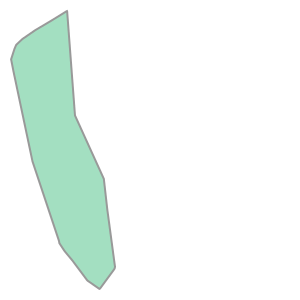

In [60]:
alpha_shape

<AxesSubplot:>

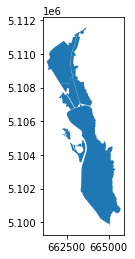

In [61]:
area.plot()

In [62]:
# change CRS

import pyproj
from shapely.ops import transform

project = pyproj.Transformer.from_proj(
    pyproj.Proj(init='epsg:25832'), # source coordinate system
    pyproj.Proj(init='epsg:4326')) # destination coordinate system


g2 = transform(project.transform, alpha_shape)  # apply projection to alpha shape polygon

c:\Users\luisa\Anaconda3\lib\site-packages\pyproj\crs\crs.py:130: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
c:\Users\luisa\Anaconda3\lib\site-packages\pyproj\crs\crs.py:130: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


In [64]:
type(g2)

shapely.geometry.polygon.Polygon

In [65]:
data["is_within"] = data.apply(lambda row: g2.intersects(Point(row["trip_origin_longitude"], row["trip_origin_latitude"])), axis = 1)

In [67]:
print('False:', len(data[data.is_within==False]), 'True:', len(data[data.is_within==True]))

False: 2050 True: 108248


In [72]:
import matplotlib.pyplot as plt

dataFalse = data[data.is_within==True]

gdp = gpd.GeoDataFrame(
    dataFalse,
    crs='EPSG:4326',
    geometry=gpd.points_from_xy(dataFalse.trip_origin_longitude, dataFalse.trip_origin_latitude))

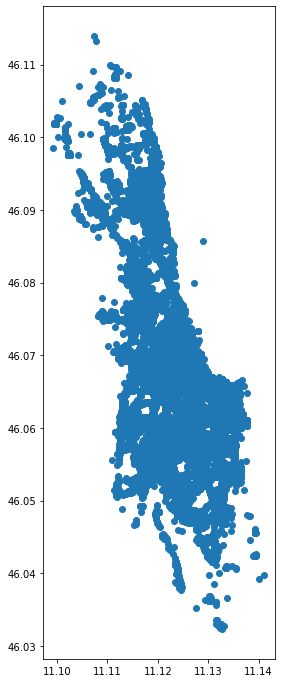

In [73]:
gdp.plot(figsize=(12,12))
plt.show()

In [74]:
data = data[data.is_within == True]

In [75]:
data = data.reset_index()

In [77]:
data = data.drop(['is_within', 'index', 'geometry'], axis=1)

In [78]:
data.head()

,operator,trip_vehicle_id,trip_start,trip_end,trip_duration_break_excluded,trip_origin_latitude,trip_origin_longitude,trip_destination_latitude,trip_destination_longitude,trip_length,trip_accuracy,unique_id
0,BIT,3s1958,2021-12-31 22:51:07+00:00,2021-12-31 23:05:16+00:00,14.150000,46.069058,11.125847,46.069185,11.125873,2420.000000,15.0,00000f26-0000-1000-85d6-5b7d6a617b60_2021-12-31
1,BIT,3s2628,2021-12-31 22:52:32+00:00,2021-12-31 23:05:22+00:00,12.816667,46.069980,11.123846,46.069166,11.125992,2290.000000,15.0,00000f55-0000-1000-85f5-5b7d6a617b60_2021-12-31
2,BIT,3S4007,2021-12-31 23:32:46+00:00,2021-12-31 23:34:37+00:00,1.850000,46.064904,11.123108,46.064540,11.120380,210.000000,15.0,00002677-0000-1000-9537-5b7d6a617b60_2021-12-31
3,BIT,3s2628,2021-12-31 23:26:03+00:00,2021-12-31 23:37:03+00:00,11.000000,46.069138,11.125999,46.067448,11.124116,950.000000,15.0,000002e4-0000-1000-9784-5b7d6a617b60_2021-12-31
4,BIT,3s1958,2021-12-31 23:26:22+00:00,2021-12-31 23:45:04+00:00,18.700000,46.069156,11.125829,46.069609,11.125088,1900.000000,15.0,0000101c-0000-1000-a03c-5b7d6a617b60_2021-12-31


### Issue 4: remove anomalous trips
Remove trips that last for hours and hours, which is likely the result of a mistake in recording or due to trips concatenation.

In [81]:
df = data.sort_values(by=['trip_start', 'trip_end', 'unique_id'])
df.trip_origin_longitude = df.trip_origin_longitude.astype(float)
df.trip_origin_latitude = df.trip_origin_latitude.astype(float)
df.trip_destination_longitude = df.trip_destination_longitude.astype(float)
df.trip_destination_latitude = df.trip_destination_latitude.astype(float)

In [83]:
# compute trip time
time_duration = []
for r in range(len(data)):
    time_duration.append(data.trip_end[r] - data.trip_start[r])
data['time_trip'] = time_duration

In [85]:
data

,operator,trip_vehicle_id,trip_start,trip_end,trip_duration_break_excluded,trip_origin_latitude,trip_origin_longitude,trip_destination_latitude,trip_destination_longitude,trip_length,trip_accuracy,unique_id,time_trip
0,BIT,3s1958,2021-12-31 22:51:07+00:00,2021-12-31 23:05:16+00:00,14.150000,46.069058,11.125847,46.069185,11.125873,2420.000000,15.0,00000f26-0000-1000-85d6-5b7d6a617b60_2021-12-31,0 days 00:14:09
1,BIT,3s2628,2021-12-31 22:52:32+00:00,2021-12-31 23:05:22+00:00,12.816667,46.069980,11.123846,46.069166,11.125992,2290.000000,15.0,00000f55-0000-1000-85f5-5b7d6a617b60_2021-12-31,0 days 00:12:50
2,BIT,3S4007,2021-12-31 23:32:46+00:00,2021-12-31 23:34:37+00:00,1.850000,46.064904,11.123108,46.064540,11.120380,210.000000,15.0,00002677-0000-1000-9537-5b7d6a617b60_2021-12-31,0 days 00:01:51
3,BIT,3s2628,2021-12-31 23:26:03+00:00,2021-12-31 23:37:03+00:00,11.000000,46.069138,11.125999,46.067448,11.124116,950.000000,15.0,000002e4-0000-1000-9784-5b7d6a617b60_2021-12-31,0 days 00:11:00
4,BIT,3s1958,2021-12-31 23:26:22+00:00,2021-12-31 23:45:04+00:00,18.700000,46.069156,11.125829,46.069609,11.125088,1900.000000,15.0,0000101c-0000-1000-a03c-5b7d6a617b60_2021-12-31,0 days 00:18:42
...,...,...,...,...,...,...,...,...,...,...,...,...,...
108243,BIT,3s2603,2022-05-04 22:18:13+00:00,2022-05-04 22:22:55+00:00,4.683333,46.066114,11.131366,46.069898,11.119706,1240.000000,15.0,0000231d-0000-1000-818d-5b7d6a617b60_2022-05-04,0 days 00:04:42
108244,BIT,3s170,2022-05-04 22:10:13+00:00,2022-05-04 22:31:08+00:00,20.916667,46.068879,11.125948,46.057510,11.125230,3350.000000,15.0,00000bd7-0000-1000-8bf7-5b7d6a617b60_2022-05-04,0 days 00:20:55
108245,BIT,3s2644,2022-05-04 22:05:28+00:00,2022-05-04 22:12:03+00:00,6.566667,46.069549,11.119470,46.061051,11.124934,1150.000000,15.0,00000ce6-0000-1000-99f6-5b7d6a617b60_2022-05-04,0 days 00:06:35
108246,BIT,3s3025,2022-05-04 22:51:02+00:00,2022-05-04 22:53:26+00:00,2.383333,46.066806,11.120345,46.061369,11.118962,670.000000,15.0,00000341-0000-1000-a011-5b7d6a617b60_2022-05-04,0 days 00:02:24


In [95]:
data.time_trip.max()

Timedelta('0 days 03:59:48')

In [104]:
data[(data.time_trip >= pd.Timedelta('0 days 02:00:00'))] # 107 trips

,operator,trip_vehicle_id,trip_start,trip_end,trip_duration_break_excluded,trip_origin_latitude,trip_origin_longitude,trip_destination_latitude,trip_destination_longitude,trip_length,trip_accuracy,unique_id,time_trip
2028,BIT,3S3883,2022-01-11 14:41:52+00:00,2022-01-11 16:42:16+00:00,120.400000,46.081932,11.122210,46.051568,11.117586,10280.000000,15.0,0000207a-0000-1000-97ea-5b7d6a617b60_2022-01-11,0 days 02:00:24
2444,BIT,3s2603,2022-01-13 03:43:35+00:00,2022-01-13 06:48:03+00:00,184.450000,46.072194,11.125243,46.069043,11.125876,1010.000000,15.0,00002407-0000-1000-8a77-5b7d6a617b60_2022-01-13,0 days 03:04:28
3798,BIT,3s3028,2022-01-23 03:54:23+00:00,2022-01-23 07:42:02+00:00,227.650000,46.069905,11.119827,46.057030,11.118009,1720.000000,15.0,00001bcd-0000-1000-885d-5b7d6a617b60_2022-01-23,0 days 03:47:39
4681,BIT,3S4155,2022-01-28 09:37:28+00:00,2022-01-28 11:37:50+00:00,120.366667,46.073595,11.120826,46.072915,11.123097,7740.000000,15.0,000015ee-0000-1000-a33e-5b7d6a617b60_2022-01-28,0 days 02:00:22
4742,BIT,3s2087,2022-01-29 18:11:36+00:00,2022-01-29 20:13:37+00:00,122.000000,46.080987,11.114079,46.055551,11.122113,4000.000000,15.0,00000d96-0000-1000-88f6-5b7d6a617b60_2022-01-29,0 days 02:02:01
...,...,...,...,...,...,...,...,...,...,...,...,...,...
101913,BIT,3s3578,2022-04-14 12:26:25+00:00,2022-04-14 14:39:53+00:00,133.466667,46.060520,11.115268,46.060586,11.115312,11400.000000,15.0,00001c47-0000-1000-8a57-5b7d6a617b60_2022-04-14,0 days 02:13:28
104490,BIT,3s2374,2022-04-23 00:15:11+00:00,2022-04-23 02:19:34+00:00,124.366667,46.067681,11.120235,46.055809,11.126145,3150.000000,15.0,0000262b-0000-1000-9bab-5b7d6a617b60_2022-04-23,0 days 02:04:23
105277,BIT,3S3899,2022-04-26 07:06:34+00:00,2022-04-26 09:08:52+00:00,122.300000,46.068430,11.124343,46.053877,11.129751,7070.000000,15.0,000010d7-0000-1000-81f7-5b7d6a617b60_2022-04-26,0 days 02:02:18
105904,BIT,3s170,2022-04-28 05:31:04+00:00,2022-04-28 07:53:02+00:00,141.966667,46.047844,11.119585,46.057150,11.124969,2190.000000,15.0,000022f6-0000-1000-8d16-5b7d6a617b60_2022-04-28,0 days 02:21:58


In [105]:
len(data)

108248

In [106]:
# keep only trips that lasted less than 2 hours
data = data[(data.time_trip < pd.Timedelta('0 days 02:00:00'))]

In [107]:
len(data)

108141

In [109]:
data = data.reset_index()

In [117]:
data = data.drop(['index', 'time_trip'], axis=1)

In [111]:
data.head(2)

,operator,trip_vehicle_id,trip_start,trip_end,trip_duration_break_excluded,trip_origin_latitude,trip_origin_longitude,trip_destination_latitude,trip_destination_longitude,trip_length,trip_accuracy,unique_id,time_trip
0,BIT,3s1958,2021-12-31 22:51:07+00:00,2021-12-31 23:05:16+00:00,14.150000,46.069058,11.125847,46.069185,11.125873,2420.000000,15.0,00000f26-0000-1000-85d6-5b7d6a617b60_2021-12-31,0 days 00:14:09
1,BIT,3s2628,2021-12-31 22:52:32+00:00,2021-12-31 23:05:22+00:00,12.816667,46.069980,11.123846,46.069166,11.125992,2290.000000,15.0,00000f55-0000-1000-85f5-5b7d6a617b60_2021-12-31,0 days 00:12:50


Save cleaned file.

In [118]:
data.to_parquet('data/tripsv3_cleaned.parquet')